# 02.1 · Arrays, linear maps and eigenvectors

CPU · Python 3.11–3.13 · seeded teaching experiment

[Open in Google Colab](https://colab.research.google.com/) — use the [ZIP setup workflow](../../docs/colab.md). No model or dataset downloads occur in this notebook.

## Learning Objectives

- Explain arrays, linear maps and eigenvectors using the chapter's assumptions.
- Translate the worked equation into Python and inspect an implementation.
- Run, visualize and critique a reproducible experiment.

## Prerequisites

[01 · Python for Computer Vision](../../01-python-for-computer-vision/README.md)

Install the repository before opening this notebook: `python -m pip install -e ".[notebooks,deep,api]"`. The deep/API extras are needed only by chapters that use them.

## 1. Introduction

Computer vision turns measurements into arrays and optimizes rules over those arrays. A scalar is one number; a vector is an ordered list; a matrix is a rectangular table. The same notation will later describe pixels, camera coordinates, weights and gradients.

## 2. Intuition

A dot product multiplies corresponding entries and adds them: it measures alignment. Matrix multiplication combines rows with columns and composes linear maps. An eigenvector keeps its direction under a map; its eigenvalue is the scale factor. Symmetric covariance matrices have orthogonal eigenvectors, which makes PCA a rotation toward directions of variation.

In [1]:
import inspect
import json
import platform
from importlib.metadata import version

import cv2
from IPython.display import Code, display

from cvzero.course.runner import lab_function, run

CHAPTER = 2
LESSON = 0
SEED = 42
AMOUNT = 1.0
print(
    {
        "python": platform.python_version(),
        "numpy": version("numpy"),
        "opencv": cv2.__version__,
        "device": "cpu",
        "seed": SEED,
    }
)

{'python': '3.12.14', 'numpy': '2.3.5', 'opencv': '4.14.0', 'device': 'cpu', 'seed': 42}


## 3. Mathematical Foundation

$$
w_{t+1}=w_t-\eta\,2(w_t-1)
$$

For loss L(w)=(w−1)², w is the current parameter, t the update number and η the positive learning rate. At w=3 and η=0.1, the gradient is 4, so the next value is 2.6.

Read the symbols aloud, predict the numerical result, and only then execute the worked example.

## 4. Visual Explanation

The chapter preview shows an actual baseline run. Read every panel title before interpreting color or brightness; some panels show a mask, an error, or a matrix rather than a photograph.

![Measured chapter baseline](../assets/lab-preview.png)

## 5. Basic Implementation

This small calculation isolates the equation from the larger pipeline. Change one number and predict its effect before rerunning.

In [2]:
w = 3.0
learning_rate = 0.1
gradient = 2 * (w - 1)
w_next = w - learning_rate * gradient
assert abs(w_next - 2.6) < 1e-12
print(w_next)

2.6


## 6. OpenCV Implementation

The relevant library is selected by the problem: OpenCV for image operations and geometry, scikit-learn for classical learning, PyTorch for differentiable models, and FastAPI for service contracts. OpenCV handles image arrays where it is useful; it does not supply every advanced model.

The lab checks an eigendecomposition numerically, compares finite differences with an analytic derivative, and detects a sinusoid through an FFT. The FFT uses complex coefficients; magnitude discards phase.

The lab function below calls the actual implementation. Inspect its source to see preprocessing, fixed hyperparameters and reported metrics.

In [3]:
display(Code(inspect.getsource(lab_function(CHAPTER)), language="python"))
result = run(CHAPTER, lesson=LESSON, seed=SEED, amount=AMOUNT)
print(json.dumps(result.metrics, indent=2))
print(result.notes)

def mathematics(lesson, seed, amount):
    rng = np.random.default_rng(seed)
    if lesson == 0:
        grid = np.array([[1., 2.], [3., 4.]])
        values, vectors = np.linalg.eigh(grid.T@grid)
        return Result('02 · Matrices, dot products and eigenvectors',
                      {'Matrix A': grid, 'A transpose times A': grid.T@grid, 'Eigenvectors (columns)': vectors},
                      metrics={'dot_product': float(np.array([1,2])@np.array([3,4])), 'eigen_residual': float(np.linalg.norm(grid.T@grid@vectors-vectors*values))})
    if lesson == 1:
        x = np.linspace(-2, 2, 100); derivative = np.gradient(x*x, x)
        w = 4.; losses = []; steps = []
        for _ in range(25):
            losses.append((w-1)**2); steps.append(w); w -= .1*amount*2*(w-1)
        return Result('02 · Derivatives and gradient descent', curves={'Analytic derivative': np.c_[x,2*x], 'Finite derivative': np.c_[x,derivative], 'Loss per update': losses}, metrics={'final_parameter': w, 'target': 1.})
    x = np.linspace(0, 1, 128, endpoint=False)
    signal = np.sin(2*np.pi*8*x)+rng.normal(0,.2*amount,len(x))
    spectrum = np.abs(np.fft.rfft(signal))
    return Result('02 · Probability, noise and Fourier frequency', {'Signal': signal, 'FFT magnitude': spectrum}, metrics={'sample_mean': float(signal.mean()), 'sample_variance': float(signal.var()), 'peak_frequency_bin': int(spectrum[1:].argmax()+1)})

{
  "dot_product": 11.0,
  "eigen_residual": 4.185297842470806e-15
}



## 7. From-Scratch Implementation

Read the following reusable reference implementation line by line. Identify input shapes, the main update or reduction, and the boundary/invalid-input policy. Its source lives in `src/cvzero/course/numerics.py`; notebooks reuse it so fixes apply everywhere. Optimized libraries are compared where matching behavior is meaningful.

In [4]:
from cvzero.course.numerics import softmax

display(Code(inspect.getsource(softmax), language="python"))

def softmax(values, axis=-1):
    values = np.asarray(values, float)
    exp = np.exp(values-values.max(axis=axis, keepdims=True))
    return exp/exp.sum(axis=axis, keepdims=True)

## 8. Experiment

Change the gradient-descent step from 0.1 to 0.3, then derive the stability interval for the quadratic before trying a larger step.

The run configuration is defined above. `lesson` selects the chapter experiment, `seed` fixes generated data or initialization, and `amount` controls the active experiment's perturbation when supported. Consult the displayed function before changing it: a fixed mathematical example may deliberately ignore a random seed or perturbation. Keep all other settings fixed when testing one hypothesis.

In [5]:
# A second independent seed checks sensitivity; fixed examples may remain identical.
repeat = run(CHAPTER, lesson=LESSON, seed=SEED + 1, amount=AMOUNT)
print(json.dumps({"baseline": result.metrics, "second_seed": repeat.metrics}, indent=2))

{
  "baseline": {
    "dot_product": 11.0,
    "eigen_residual": 4.185297842470806e-15
  },
  "second_seed": {
    "dot_product": 11.0,
    "eigen_residual": 4.185297842470806e-15
  }
}


## 9. Visualization

These figures are generated by the current run. The second plot uses the second seed. Compare the numerical report with the visible result; a single scalar rarely explains every failure.

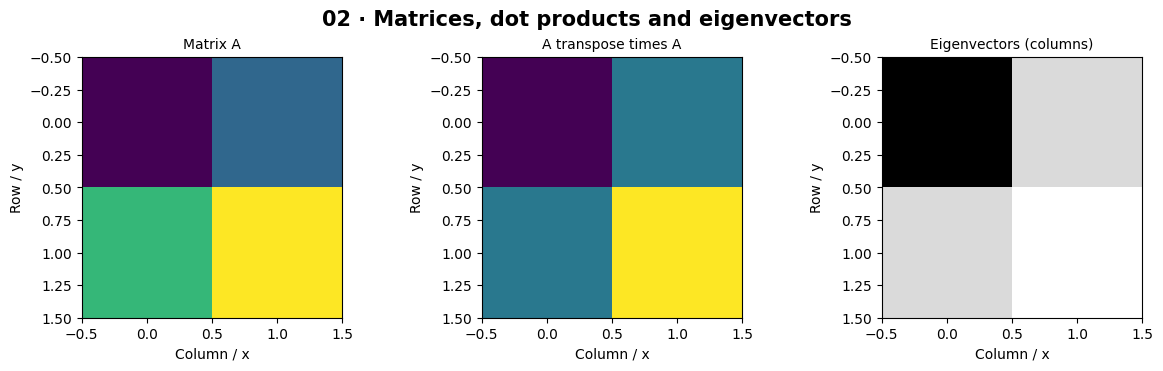

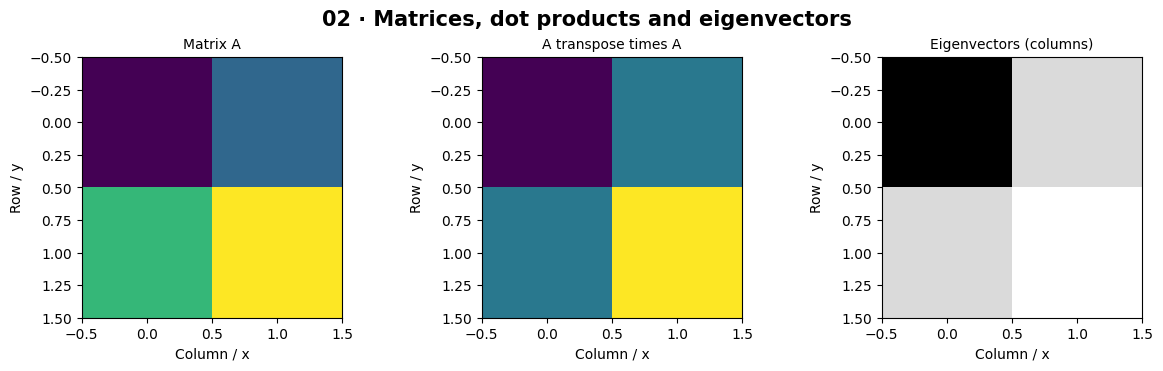

In [6]:
display(result.plot())
display(repeat.plot())

## 10. Real-World Application

The chapter mini project is **Visual Math Workbook**. Translate small equations into array operations before using models. Start with the generated data so expected geometry or labels are known, then use a separately documented real dataset. Do not transfer synthetic metrics to a real deployment claim.

## 11. Common Mistakes

Elementwise multiplication A*B is not matrix multiplication A@B. A low loss after one example says nothing about generalization.

Check shape, dtype, units, split and coordinate conventions before tuning an algorithm.

## 12. Exercises

- **Easy:** Reproduce the worked numerical example by hand and add a second case.
- **Medium:** Change the gradient-descent step from 0.1 to 0.3, then derive the stability interval for the quadratic before trying a larger step.
- **Hard:** Create a failure case for one assumption stated in this lesson and propose a measurable remedy.

## 13. Challenge

Build a two-parameter least-squares line fitter, derive both partial derivatives, and compare iterative updates with a closed-form solution.

Write acceptance criteria before coding. No challenge solution is included beside the question.

## 14. Summary

A dot product multiplies corresponding entries and adds them: it measures alignment. Matrix multiplication combines rows with columns and composes linear maps. An eigenvector keeps its direction under a map; its eigenvalue is the scale factor. Symmetric covariance matrices have orthogonal eigenvectors, which makes PCA a rotation toward directions of variation.

**Checkpoint:** explain the mechanism, implement a small case, modify one parameter, debug a failure and apply it to a new example. Record evidence for all five.

## 15. Next Step

Continue with **Derivatives, gradients and optimization** in this chapter.

[Primary reference](https://numpy.org/doc/stable/reference/routines.linalg.html) · [Chapter exercises](../exercises/beginner.md) · [Mini project](../mini-project/README.md)